### IMPORTS

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

### SPLITTING THE TRAIN AND TEST DATA

In [2]:
df = pd.read_csv('asianpaint.csv')
# df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%Y')
numR = len(df) * 0.65
train = df.head(int(numR)).copy()
test = df.tail(len(df) - int(numR)).copy()

### PLOTTING THE TRAIN AND TEST DATASET

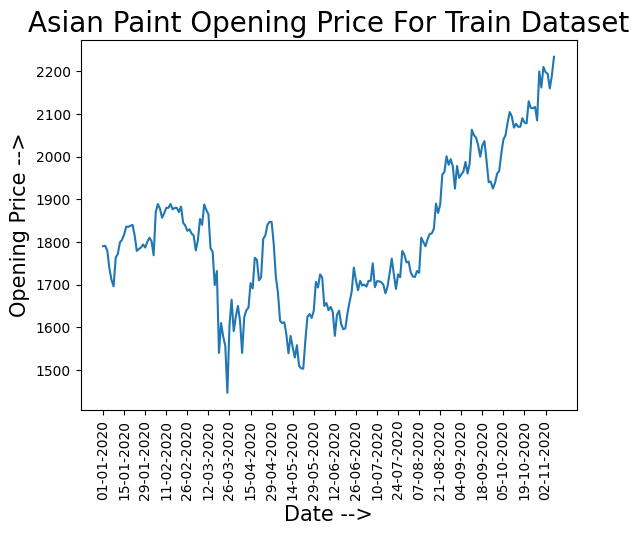

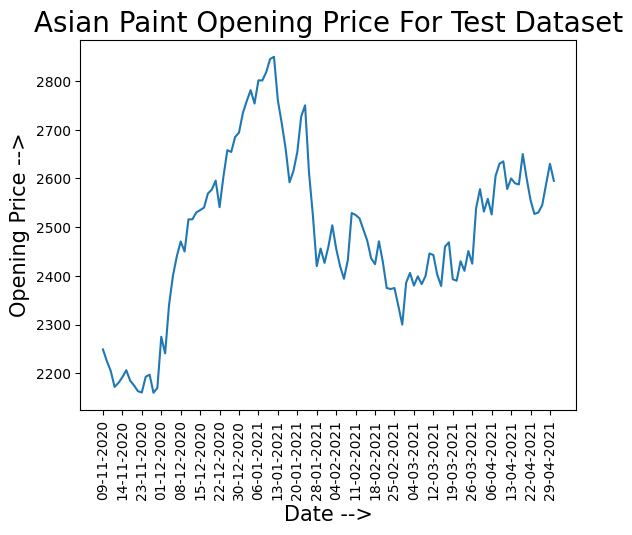

In [3]:
plt.plot(range(len(train)), train['Open'])
plt.xticks(ticks = range(len(train))[::10], labels = train['Date'][::10], rotation = 90)
plt.xlabel('Date -->', fontsize = 15)
plt.ylabel('Opening Price -->', fontsize = 15)
plt.title('Asian Paint Opening Price For Train Dataset', fontsize = 20)
plt.show()

plt.plot(range(len(test)), test['Open'])
plt.xticks(ticks = range(len(test))[::5], labels = test['Date'][::5], rotation = 90)
plt.xlabel('Date -->', fontsize = 15)
plt.ylabel('Opening Price -->', fontsize = 15)
plt.title('Asian Paint Opening Price For Test Dataset', fontsize = 20)
plt.show()

### TRAINING ONE-DAY LAG AR MODEL

In [4]:
class AutoRegression:
    def __init__(self):
        self.coef = None
        self.intercept = None

    def fit(self, y):
        y = np.array(y, dtype = np.float64)    
        Y = y[1 :]
        laggedY = y[: -1]
        self.coef = np.sum((Y - np.mean(Y)) * (laggedY - np.mean(laggedY))) / np.sum((laggedY - np.mean(laggedY)) ** 2)
        self.intercept = np.mean(Y) - self.coef * np.mean(laggedY)

    def predict(self, y):
        y = np.array(y, dtype = np.float64)
        laggedY = y[: -1]
        Y =  self.intercept + self.coef * laggedY
        yPred = np.append(y[0], Y)
        return yPred
    
    def calculateErrors(self, y, yPred):
        y = np.array(y, dtype = np.float64)
        yPred = np.array(yPred, dtype = np.float64)
        rmspe = np.sqrt(np.mean(((y - yPred) / y) ** 2)) * 100
        mape = np.mean(np.abs((y - yPred) / y)) * 100
        return rmspe, mape

In [5]:
ar = AutoRegression()
ar.fit(train['Open'])
print('Intercept: ', ar.intercept)
print('Coefficient: ', ar.coef)

Intercept:  22.702773601834906
Coefficient:  0.9885847855594729


### USING THE AR MODEL ON TEST DATA

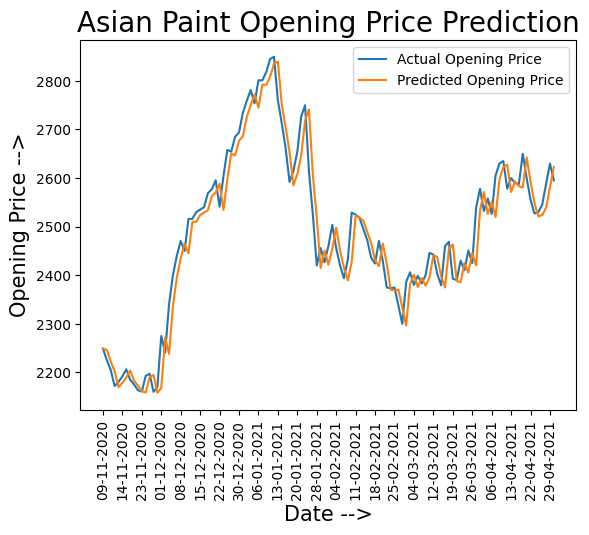

In [6]:
yPred = ar.predict(test['Open'])
predResult = test.copy()
predResult['OpenPred'] = yPred

plt.plot(range(len(test)), test['Open'], label = 'Actual Opening Price')
plt.plot(range(len(test)), predResult['OpenPred'], label = 'Predicted Opening Price')
plt.xticks(ticks = range(len(test))[::5], labels = test['Date'][::5], rotation = 90)
plt.xlabel('Date -->', fontsize = 15)
plt.ylabel('Opening Price -->', fontsize = 15)
plt.title('Asian Paint Opening Price Prediction', fontsize = 20)
plt.legend()
plt.show()

### COMPUTE RMSE(%) AND MAPE(%)

In [7]:
rmspe, mape = ar.calculateErrors(test['Open'], yPred)
print('RMSPE(%): ', rmspe)
print('MAPE(%): ', mape)

RMSPE(%):  1.7781774149177598
MAPE(%):  1.411973160090862
